In [21]:
!pip install torch torchvision torchaudio
!pip install scikit-learn pandas matplotlib
!pip install pytorch-tabnet shap

In [22]:
import os, math, json, random, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_fscore_support

# Reproducibility
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

In [23]:
# Try to load Kaggle-style 'crop_recommendation.csv' if present; otherwise synthesize.
csv_candidates = [
    'dataset/Crop_recommendation.csv'
]

df = None
for p in csv_candidates:
    if os.path.exists(p):
        df = pd.read_csv(p)
        break

if df is None:
    # Synthesize a dataset with similar structure
    n = 2200
    rng = np.random.default_rng(123)
    N = rng.normal(70, 20, n).clip(0, 140)
    P = rng.normal(50, 18, n).clip(0, 120)
    K = rng.normal(48, 20, n).clip(0, 140)
    temperature = rng.normal(24, 6, n).clip(5, 40)
    humidity = rng.normal(65, 15, n).clip(20, 100)
    ph = rng.normal(6.5, 0.7, n).clip(3.5, 8.5)
    rainfall = rng.normal(100, 60, n).clip(0, 300)

    # Create 22 synthetic crops with rules to make learnable structure
    crops = [f"crop_{i:02d}" for i in range(22)]
    y_idx = []
    for i in range(n):
        key = 0
        key += (rainfall[i] > 120)
        key += (humidity[i] > 70) * 2
        key += (temperature[i] > 28) * 3
        key += (ph[i] > 7.0) * 4
        key += (N[i] > 80) * 5
        key += (K[i] < 35) * 7
        # Map key to class id
        cls = key % 22
        y_idx.append(cls)

    df = pd.DataFrame({
        'N': N, 'P': P, 'K': K, 'temperature': temperature,
        'humidity': humidity, 'ph': ph, 'rainfall': rainfall,
        'label': [crops[i] for i in y_idx]
    })

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [24]:
# Features and target
feature_cols = ['N','P','K','temperature','humidity','ph','rainfall']
target_col = 'label'

X = df[feature_cols].values.astype('float32')
le = LabelEncoder()
y = le.fit_transform(df[target_col].values)
num_classes = len(le.classes_)

# Identify classes with only one sample
class_counts = np.bincount(y)
classes_to_remove = np.where(class_counts < 2)[0]

# Filter data to remove samples from classes with less than 2 members
filtered_indices = [i for i, label in enumerate(y) if label not in classes_to_remove]
X_filtered = X[filtered_indices]
y_filtered = y[filtered_indices]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=seed, stratify=y_filtered)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype('float32')
X_val_s = scaler.transform(X_val).astype('float32')
X_test_s = scaler.transform(X_test).astype('float32')

X_train_t = torch.tensor(X_train_s)
X_val_t   = torch.tensor(X_val_s)
X_test_t  = torch.tensor(X_test_s)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)

X_train_t.shape, num_classes

(torch.Size([1540, 7]), 22)

In [25]:

class MLPNet(nn.Module):
    def __init__(self, in_dim, num_classes, width=256, depth=4, dropout=0.2):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.ReLU(), nn.LayerNorm(width), nn.Dropout(dropout)]
            d = width
        layers += [nn.Linear(d, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [18]:

# Simple TabTransformer-like model for numerical features:
# Quantize each feature into bins, embed them, pass through TransformerEncoder, mean-pool, classify.
class TabTransformer(nn.Module):
    def __init__(self, num_features, num_classes, bins_per_feature=10, d_model=64, nhead=4, nlayers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.bins_per_feature = bins_per_feature

        # Per-feature embeddings (each feature has its own vocabulary of bins)
        self.embeddings = nn.ModuleList([nn.Embedding(bins_per_feature, d_model) for _ in range(num_features)])
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.cls = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_classes))

        # Buffers for quantization thresholds per feature
        self.register_buffer("bin_edges", torch.zeros(num_features, bins_per_feature-1))

    def fit_bins(self, Xnp):
        # Use quantiles to get roughly balanced bins
        import numpy as np
        edges = []
        for j in range(self.num_features):
            q = np.quantile(Xnp[:, j], np.linspace(0, 1, self.bins_per_feature+1)[1:-1])
            edges.append(q.astype('float32'))
        self.bin_edges = torch.tensor(np.stack(edges), dtype=torch.float32)

    def _digitize(self, x):
        # x: (B, F) float tensor
        # return: (B, F) long tensor of bin ids in [0, bins_per_feature-1]
        B, F = x.shape
        device = x.device
        ids = torch.zeros_like(x, dtype=torch.long, device=device)
        for j in range(F):
            edges = self.bin_edges[j].to(device)
            # Count how many edges x[:, j] is greater than
            ids[:, j] = torch.bucketize(x[:, j], edges)
        return ids

    def forward(self, x):
        # x: (B, F) standardized floats
        ids = self._digitize(x)
        tok_list = []
        for j in range(self.num_features):
            tok_list.append(self.embeddings[j](ids[:, j]))
        tokens = torch.stack(tok_list, dim=1)  # (B, F, d_model)
        z = self.encoder(tokens)               # (B, F, d_model)
        z_mean = z.mean(dim=1)                 # mean-pool over features
        return self.cls(z_mean)



In [26]:

def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3, weight_decay=1e-4, device='cpu'):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    best_val = -1.0
    history = {'train_acc':[], 'val_acc':[]}

    for epoch in range(1, epochs+1):
        model.train()
        correct = total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            pred = logits.argmax(dim=1)
            correct += (pred==yb).sum().item(); total += yb.size(0)
        train_acc = correct/total
        history['train_acc'].append(train_acc)

        # validation
        model.eval()
        vs, vt = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                pred = logits.argmax(dim=1)
                vs += (pred==yb).sum().item(); vt += yb.size(0)
        val_acc = vs/vt
        history['val_acc'].append(val_acc)

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k:v.cpu() for k,v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d}: train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

        # Early stopping patience (simple): stop if no improvement for 30 epochs
        if epoch > 60 and max(history['val_acc'][-30:]) < best_val - 1e-6:
            break

    model.load_state_dict(best_state)
    return model, history


In [27]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
mlp = MLPNet(in_dim=len(feature_cols), num_classes=num_classes, width=256, depth=4, dropout=0.2)
mlp, hist_mlp = train_model(mlp, train_loader, val_loader, epochs=120, lr=1e-3, weight_decay=1e-4, device=device)

# Evaluate
def evaluate(model, loader, device='cpu'):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            y_prob.append(probs)
            y_true.append(yb.numpy())
            y_pred.append(logits.argmax(dim=1).cpu().numpy())
    import numpy as np
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred); y_prob = np.concatenate(y_prob)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    return y_true, y_pred, y_prob, acc, macro_f1

y_true_mlp, y_pred_mlp, y_prob_mlp, acc_mlp, f1_mlp = evaluate(mlp, test_loader, device=device)
print("MLP Test Accuracy:", acc_mlp, " Macro-F1:", f1_mlp)


Epoch 010: train_acc=0.9649 val_acc=0.9939
Epoch 020: train_acc=0.9753 val_acc=0.9939
Epoch 030: train_acc=0.9825 val_acc=0.9939
Epoch 040: train_acc=0.9818 val_acc=0.9970
Epoch 050: train_acc=0.9805 val_acc=1.0000
Epoch 060: train_acc=0.9903 val_acc=0.9939
Epoch 070: train_acc=0.9916 val_acc=0.9939
Epoch 080: train_acc=0.9935 val_acc=0.9970
MLP Test Accuracy: 0.9878787878787879  Macro-F1: 0.9878653048842149


In [28]:

tabtr = TabTransformer(num_features=len(feature_cols), num_classes=num_classes, bins_per_feature=12, d_model=64, nhead=4, nlayers=3, dim_feedforward=128, dropout=0.1)
tabtr.fit_bins(X_train_s)  # fit quantile bins on training data
tabtr, hist_tabtr = train_model(tabtr, train_loader, val_loader, epochs=150, lr=2e-3, weight_decay=1e-4, device=device)

y_true_tt, y_pred_tt, y_prob_tt, acc_tt, f1_tt = evaluate(tabtr, test_loader, device=device)
print("Transformer Test Accuracy:", acc_tt, " Macro-F1:", f1_tt)

C:\Users\Suma\AppData\Local\Temp\ipykernel_23340\1676055242.py:36: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen/native/BucketizationUtils.h:34.)
  ids[:, j] = torch.bucketize(x[:, j], edges)


Epoch 010: train_acc=0.9870 val_acc=0.9636
Epoch 020: train_acc=1.0000 val_acc=0.9788
Epoch 030: train_acc=1.0000 val_acc=0.9697
Epoch 040: train_acc=1.0000 val_acc=0.9758
Epoch 050: train_acc=1.0000 val_acc=0.9727
Epoch 060: train_acc=1.0000 val_acc=0.9697
Epoch 070: train_acc=0.9922 val_acc=0.9606
Transformer Test Accuracy: 0.9636363636363636  Macro-F1: 0.9636220066784257


In [29]:
!pip install pytorch-tabnet -q

In [30]:
use_tabnet = False
acc_tn = None
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    use_tabnet = True
except Exception as e:
    print("TabNet not available; skipping. You can install 'pytorch-tabnet' to enable it.")

if use_tabnet:
    # TabNet expects numpy arrays
    tn = TabNetClassifier(verbose=0, device_name='auto')
    tn.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], eval_name=["val"], eval_metric=["accuracy"], max_epochs=200, patience=50, batch_size=256, virtual_batch_size=128)
    y_pred_tn = tn.predict(X_test_s)
    acc_tn = accuracy_score(y_test, y_pred_tn)
    f1_tn = f1_score(y_test, y_pred_tn, average='macro')
    print("TabNet Test Accuracy:", acc_tn, " Macro-F1:", f1_tn)


Early stopping occurred at epoch 106 with best_epoch = 56 and best_val_accuracy = 0.99697
TabNet Test Accuracy: 0.9878787878787879  Macro-F1: 0.9877330330959363


c:\Users\Suma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


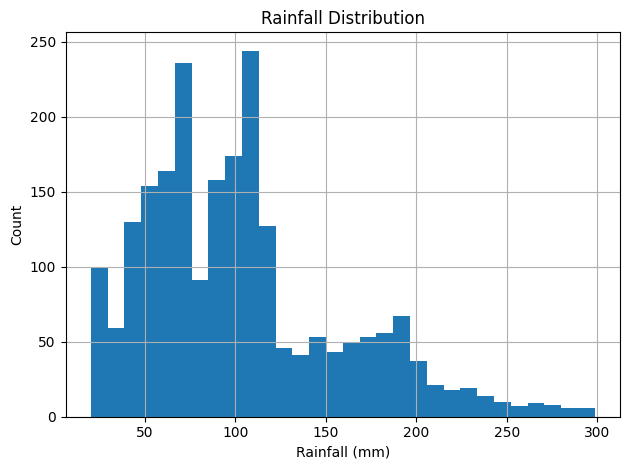

In [31]:
# 1) Histogram of rainfall
import os
plt.figure()
df['rainfall'].hist(bins=30)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)"); plt.ylabel("Count")
plt.tight_layout()
# Create the directory if it doesn't exist
output_dir = '/mnt/data/'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'fig_hist_rainfall.png')); plt.show()

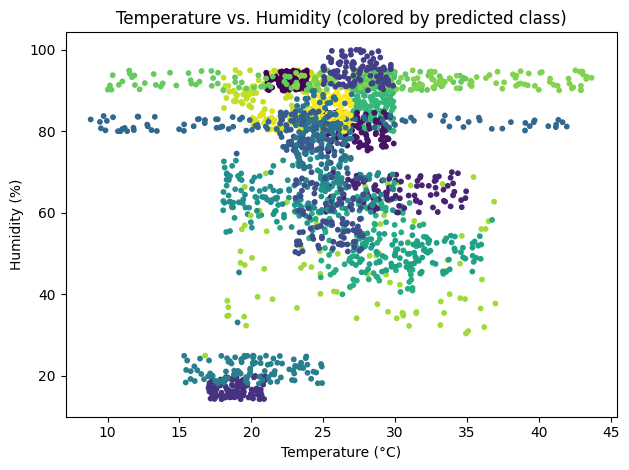

In [32]:
# 2) Scatter: temperature vs humidity colored by predicted class (from Transformer model)
plt.figure()
# get predictions for entire dataset using transformer model
with torch.no_grad():
    X_all = scaler.transform(df[feature_cols].values.astype('float32'))
    preds_all = []
    bs = 512
    for i in range(0, len(X_all), bs):
        xb = torch.tensor(X_all[i:i+bs], dtype=torch.float32)
        logits = tabtr(xb.to(device))
        preds_all.append(logits.argmax(dim=1).cpu().numpy())
    import numpy as np
    preds_all = np.concatenate(preds_all)

plt.scatter(df['temperature'].values, df['humidity'].values, c=preds_all, s=10)
plt.title("Temperature vs. Humidity (colored by predicted class)")
plt.xlabel("Temperature (°C)"); plt.ylabel("Humidity (%)")
plt.tight_layout(); plt.savefig('/mnt/data/fig_scatter_temp_humidity.png'); plt.show()


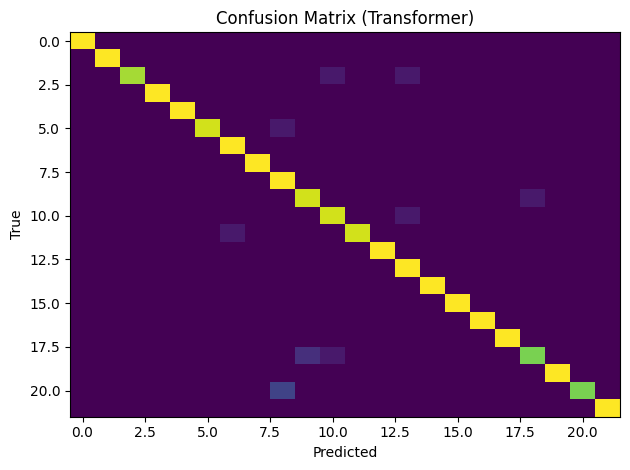

In [33]:
# 3) Confusion matrix (Transformer)
cm = confusion_matrix(y_test, y_pred_tt)
plt.figure()
plt.imshow(cm, aspect='auto')
plt.title("Confusion Matrix (Transformer)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.savefig('/mnt/data/fig_confusion_matrix.png'); plt.show()

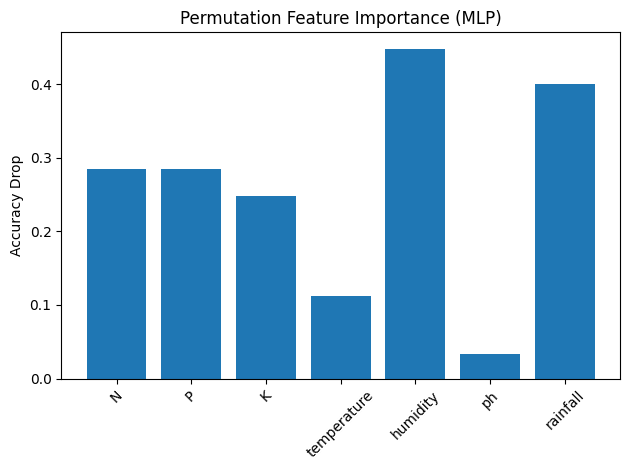

In [34]:
# 4) Permutation feature importance (for MLP) using validation set
import numpy as np
def permutation_importance(model, X_val, y_val, baseline_acc=None, device='cpu'):
    if baseline_acc is None:
        loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long)), batch_size=256, shuffle=False)
        _, _, _, base_acc, _ = evaluate(model, loader, device=device)
    else:
        base_acc = baseline_acc
    drops = []
    Xv = X_val.copy()
    for j in range(Xv.shape[1]):
        Xperm = Xv.copy()
        rng = np.random.default_rng(0)
        rng.shuffle(Xperm[:, j])
        loader = DataLoader(TensorDataset(torch.tensor(Xperm), torch.tensor(y_val, dtype=torch.long)), batch_size=256, shuffle=False)
        _, _, _, acc_p, _ = evaluate(model, loader, device=device)
        drops.append(base_acc - acc_p)
    return np.array(drops)

# Compute
loader_val = DataLoader(TensorDataset(torch.tensor(X_val_s), torch.tensor(y_val, dtype=torch.long)), batch_size=256, shuffle=False)
_, _, _, acc_val_mlp, _ = evaluate(mlp, loader_val, device=device)
drops = permutation_importance(mlp, X_val_s, y_val, baseline_acc=acc_val_mlp, device=device)

plt.figure()
plt.bar(range(len(feature_cols)), drops)
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45)
plt.title("Permutation Feature Importance (MLP)")
plt.ylabel("Accuracy Drop")
plt.tight_layout(); plt.savefig('/mnt/data/fig_feature_importance.png'); plt.show()


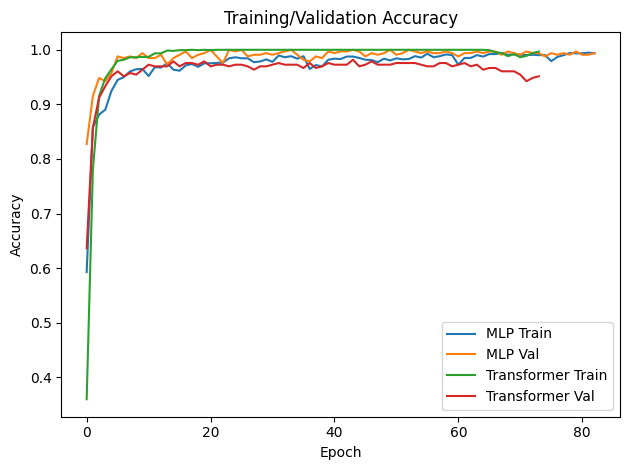

In [35]:
# 5) Training curves
plt.figure()
plt.plot(hist_mlp['train_acc'], label='MLP Train')
plt.plot(hist_mlp['val_acc'], label='MLP Val')
plt.plot(hist_tabtr['train_acc'], label='Transformer Train')
plt.plot(hist_tabtr['val_acc'], label='Transformer Val')
plt.title("Training/Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout(); plt.savefig('/mnt/data/fig_training_curves.png'); plt.show()

In [36]:
results = {
    "mlp": {"acc": float(acc_mlp), "macro_f1": float(f1_mlp)},
    "transformer": {"acc": float(acc_tt), "macro_f1": float(f1_tt)},
}
if acc_tn is not None:
    results["tabnet"] = {"acc": float(acc_tn)}

pd.DataFrame(results).to_csv("/mnt/data/results_summary.csv")

# Save label encoder and scaler parameters (for deployment later)
import pickle
with open("/mnt/data/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
with open("/mnt/data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save trained models
torch.save(mlp.state_dict(), "/mnt/data/model_mlp.pt")
torch.save(tabtr.state_dict(), "/mnt/data/model_tabtransformer.pt")

print("Artifacts saved in /mnt/data:")
print("- fig_*.png")
print("- results_summary.csv")
print("- model_mlp.pt, model_tabtransformer.pt")
print("- label_encoder.pkl, scaler.pkl")

Artifacts saved in /mnt/data:
- fig_*.png
- results_summary.csv
- model_mlp.pt, model_tabtransformer.pt
- label_encoder.pkl, scaler.pkl
